<a href="https://colab.research.google.com/github/harshaesmayil/Face_Recognition/blob/main/Face_Recognition_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

dataset_path = "/content/drive/MyDrive/Pattern Recognition/ORL"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def load_orl_dataset(path):
    images, labels = [], []

    # Check if path exists
    if not os.path.exists(path):
        print(f"❌ Error: Path '{path}' not found. Check your Drive folder name!")
        return None, None

    # Get sorted list of person folders (s1, s2, etc.)
    person_folders = sorted([f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))])

    for label, person in enumerate(person_folders):
        person_path = os.path.join(path, person)
        for image_name in sorted(os.listdir(person_path)):
            img_path = os.path.join(person_path, image_name)

            # Read image in grayscale
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, (92, 112)) # 92x112 = 10304 features
                images.append(img.flatten())
                labels.append(label)

    return np.array(images), np.array(labels)

# Step 4: Load dataset
X, y = load_orl_dataset(dataset_path)

if X is not None:
    # Step 5: Normalize (Scale pixels to 0-1)
    X = X / 255.0

    # Step 6: Train-Test Split (70% Train, 30% Test)
    # random_state=42 ensures your team gets the same results every time
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

    print(f"✅ Dataset loaded successfully!")
    print(f"Total Images: {X.shape[0]}")
    print(f"Features per Image: {X.shape[1]} (92x112 pixels)")
    print(f"Training set: {X_train.shape[0]} images")
    print(f"Testing set: {X_test.shape[0]} images")

✅ Dataset loaded successfully!
Total Images: 400
Features per Image: 10304 (92x112 pixels)
Training set: 280 images
Testing set: 120 images


In [ ]:
# PCA - Reduce to 100 components
pca = PCA(n_components=100)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# k-NN on PCA
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_pca, y_train)
pca_acc = accuracy_score(y_test, knn.predict(X_test_pca))

print(f"PCA + k-NN Accuracy: {pca_acc * 100:.2f}%")

PCA + k-NN Accuracy: 92.50%


In [ ]:
# Select the best 100 pixels using ANOVA F-test
selector = SelectKBest(score_func=f_classif, k=100)
X_train_filter = selector.fit_transform(X_train, y_train)
X_test_filter = selector.transform(X_test)

# k-NN on Filtered Data
knn.fit(X_train_filter, y_train)
filter_acc = accuracy_score(y_test, knn.predict(X_test_filter))

print(f"SelectKBest (Filter) + k-NN Accuracy: {filter_acc * 100:.2f}%")

SelectKBest (Filter) + k-NN Accuracy: 56.67%


In [ ]:
# Forward Selection (from 100 PCA features down to 50)
print("Running Forward Selection...")
sfs_fwd = SequentialFeatureSelector(knn, n_features_to_select=50, direction='forward', n_jobs=-1)
X_train_fwd = sfs_fwd.fit_transform(X_train_pca, y_train)
X_test_fwd = sfs_fwd.transform(X_test_pca)
knn.fit(X_train_fwd, y_train)
fwd_acc = accuracy_score(y_test, knn.predict(X_test_fwd))

# Backward Elimination (from 100 PCA features down to 50)
print("Running Backward Elimination...")
sfs_bwd = SequentialFeatureSelector(knn, n_features_to_select=50, direction='backward', n_jobs=-1)
X_train_bwd = sfs_bwd.fit_transform(X_train_pca, y_train)
X_test_bwd = sfs_bwd.transform(X_test_pca)
knn.fit(X_train_bwd, y_train)
bwd_acc = accuracy_score(y_test, knn.predict(X_test_bwd))

print(f"Forward Accuracy: {fwd_acc*100:.2f}% | Backward Accuracy: {bwd_acc*100:.2f}%")

Running Forward Selection...
Running Backward Elimination...
Forward Accuracy: 92.50% | Backward Accuracy: 91.67%


              Method  Accuracy (%)
0          PCA + kNN     92.500000
1  SelectKBest + kNN     56.666667
2    Forward Wrapper     92.500000
3   Backward Wrapper     91.666667


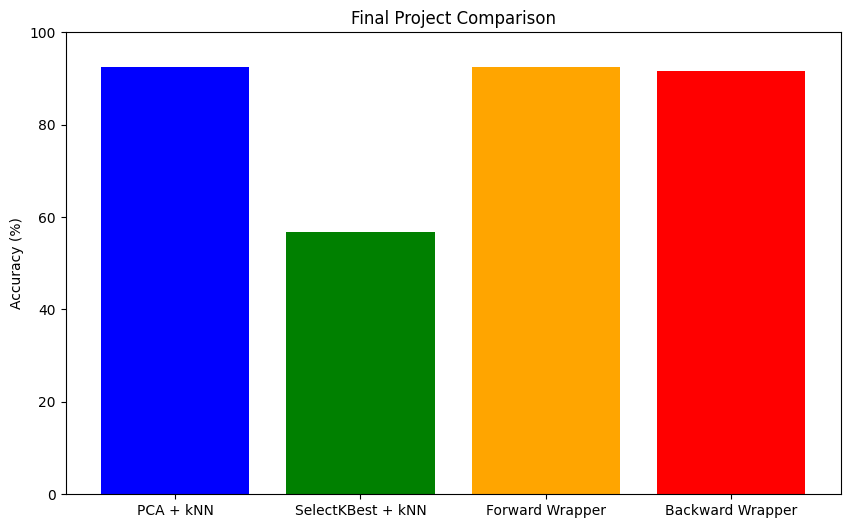

In [ ]:
import pandas as pd

results = {
    "Method": ["PCA + kNN", "SelectKBest + kNN", "Forward Wrapper", "Backward Wrapper"],
    "Accuracy (%)": [pca_acc*100, filter_acc*100, fwd_acc*100, bwd_acc*100]
}

df = pd.DataFrame(results)
print(df)

#final bar chart
plt.figure(figsize=(10, 6))
plt.bar(df["Method"], df["Accuracy (%)"], color=['blue', 'green', 'orange', 'red'])
plt.ylabel('Accuracy (%)')
plt.title('Final Project Comparison')
plt.ylim(0, 100)
plt.show()